# 1: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2: Load Dataset

In [3]:
df = pd.read_excel(r"C:\Users\aftab\Downloads\financial_analytics_5000_rows.xlsx")

df.head()

,Transaction_ID,Date,Year,Month,Quarter,Region,Customer_ID,Customer_Segment,Department,Product,...,COGS,Marketing_Expense,Operating_Expense,Total_Expense,Profit,Profit_Margin,Payment_Method,Payment_Status,Budget_Target,Variance_vs_Budget
0,TXN-00001,2023-08-17,2023,Aug,Q3,Dubai,CUST-0048,SME,Marketing,Software Subscription,...,15615.89,1557.96,4267.12,21440.97,4267.13,0.1660,Online,Paid,23293.64,2414.46
1,TXN-00002,2023-02-24,2023,Feb,Q1,Abu Dhabi,CUST-0111,Retail,Sales,Data Analytics Package,...,12705.73,609.93,4629.25,17944.91,11968.20,0.4001,Bank Transfer,Paid,32588.59,-2675.48
2,TXN-00003,2025-02-17,2025,Feb,Q1,Ras Al Khaimah,CUST-0151,Hospitality,Logistics,Consulting Service,...,11063.81,1477.45,2772.88,15314.14,7849.28,0.3389,Cash,Paid,27146.02,-3982.60
3,TXN-00004,2024-01-29,2024,Jan,Q1,Umm Al Quwain,CUST-0187,SME,Operations,Consulting Service,...,1757.97,253.97,579.17,2591.11,969.91,0.2724,Cash,Paid,3539.79,21.23
4,TXN-00005,2024-03-05,2024,Mar,Q1,Fujairah,CUST-0353,Hospitality,Marketing,Cloud Support,...,27375.52,1351.52,6464.90,35191.94,9459.36,0.2118,Cash,Paid,41481.98,3169.32


# 3: Dataset Information

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Transaction_ID      5000 non-null   str           
 1   Date                5000 non-null   datetime64[us]
 2   Year                5000 non-null   int64         
 3   Month               5000 non-null   str           
 4   Quarter             5000 non-null   str           
 5   Region              5000 non-null   str           
 6   Customer_ID         5000 non-null   str           
 7   Customer_Segment    5000 non-null   str           
 8   Department          5000 non-null   str           
 9   Product             5000 non-null   str           
 10  Units_Sold          5000 non-null   int64         
 11  Unit_Price          5000 non-null   float64       
 12  Gross_Revenue       5000 non-null   float64       
 13  Discount            5000 non-null   float64       
 14  Net

# 4: Check Null Values

In [13]:
df.isnull().sum()

Transaction_ID        0
Date                  0
Year                  0
Month                 0
Quarter               0
Region                0
Customer_ID           0
Customer_Segment      0
Department            0
Product               0
Units_Sold            0
Unit_Price            0
Gross_Revenue         0
Discount              0
Net_Revenue           0
COGS                  0
Marketing_Expense     0
Operating_Expense     0
Total_Expense         0
Profit                0
Profit_Margin         0
Payment_Method        0
Payment_Status        0
Budget_Target         0
Variance_vs_Budget    0
dtype: int64

# 5: Descriptive Statistics

In [14]:
df.describe()

,Date,Year,Units_Sold,Unit_Price,Gross_Revenue,Discount,Net_Revenue,COGS,Marketing_Expense,Operating_Expense,Total_Expense,Profit,Profit_Margin,Budget_Target,Variance_vs_Budget
count,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2024-06-29 08:33:12.960000,2023.995400,11.410600,2639.721368,23340.547240,1621.389712,21719.157528,12639.783048,1080.221224,2493.522680,16213.526952,5505.630576,0.278337,22397.305084,-678.147556
min,2023-01-01 00:00:00,2023.000000,1.000000,739.590000,759.660000,0.330000,675.630000,326.440000,23.500000,47.090000,452.590000,-4419.190000,-0.052100,601.220000,-15111.210000
25%,2023-09-25 00:00:00,2023.000000,4.000000,1369.447500,11096.595000,362.042500,10394.887500,5417.355000,453.652500,1052.550000,7100.315000,2368.302500,0.197250,10661.607500,-1810.357500
50%,2024-07-02 12:00:00,2024.000000,8.000000,2175.940000,20582.530000,921.380000,19328.640000,10056.055000,876.655000,2037.230000,13253.490000,4784.865000,0.287200,19707.210000,-334.660000
75%,2025-04-02 06:00:00,2025.000000,19.000000,3913.055000,31900.042500,1998.195000,29831.937500,15899.607500,1495.872500,3410.027500,20831.245000,7788.572500,0.366300,30868.397500,613.752500
max,2025-12-31 00:00:00,2025.000000,30.000000,6099.980000,91750.490000,15981.780000,87755.450000,71410.320000,6752.430000,14558.550000,89320.240000,24823.750000,0.557300,102158.680000,8596.110000
std,NaN,0.820679,8.794605,1472.866667,16149.472303,2060.838284,14742.103745,10634.702602,854.465930,1949.734694,12997.022743,3967.076852,0.117774,15430.809856,2340.680994


# 6: Check Duplicates

In [4]:
df.duplicated().sum()

np.int64(0)

# 7: Revenue Trend by Month

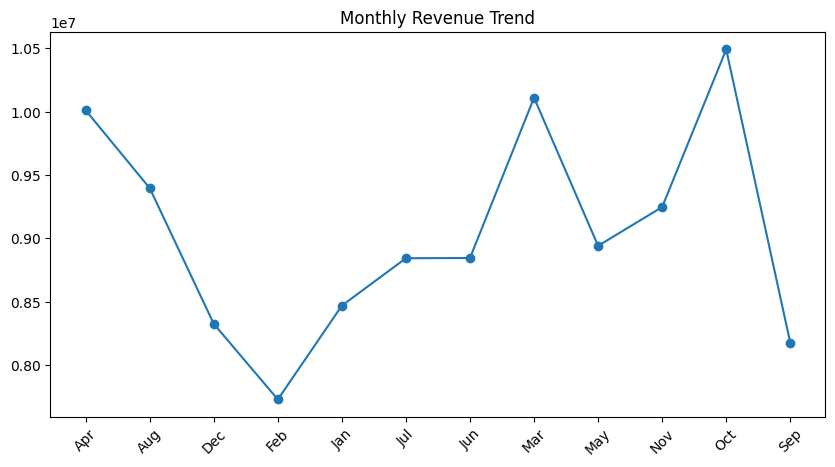

In [5]:
monthly_rev = df.groupby('Month', as_index=False)['Net_Revenue'].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_rev['Month'], monthly_rev['Net_Revenue'], marker='o')
plt.title('Monthly Revenue Trend')
plt.xticks(rotation=45)
plt.show()

# 8: Profit by Region

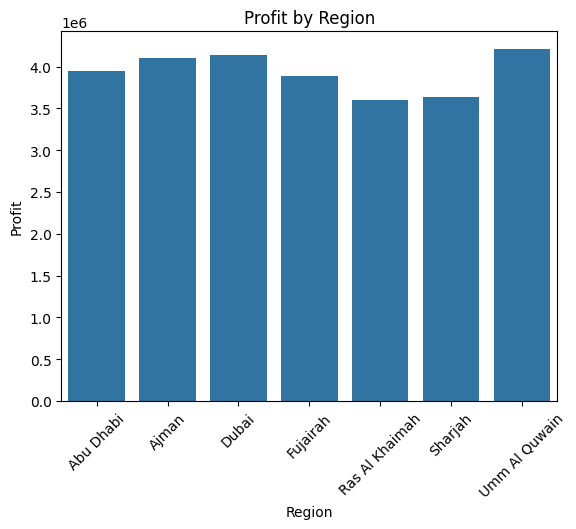

In [6]:
region_profit = df.groupby('Region', as_index=False)['Profit'].sum()

sns.barplot(x='Region', y='Profit', data=region_profit)

plt.title('Profit by Region')
plt.xticks(rotation=45)
plt.show()

# 9: Top 10 Products by Revenue

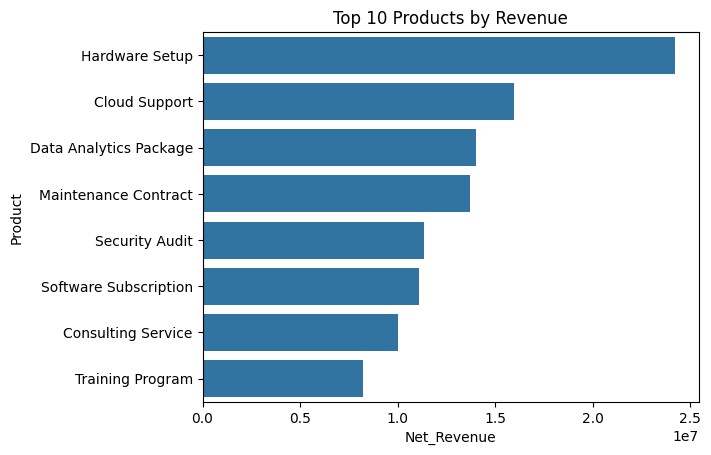

In [7]:
top_products = df.groupby('Product', as_index=False)['Net_Revenue'].sum()

top_products = top_products.sort_values(
    by='Net_Revenue',
    ascending=False
).head(10)

sns.barplot(
    x='Net_Revenue',
    y='Product',
    data=top_products
)

plt.title('Top 10 Products by Revenue')
plt.show()

# 10: Customer Segment Analysis

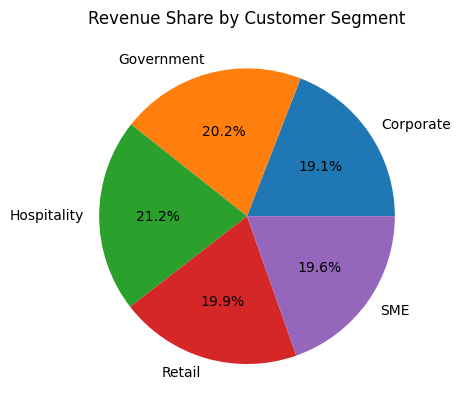

In [8]:
segment = df.groupby(
    'Customer_Segment',
    as_index=False
)['Net_Revenue'].sum()

plt.pie(
    segment['Net_Revenue'],
    labels=segment['Customer_Segment'],
    autopct='%1.1f%%'
)

plt.title('Revenue Share by Customer Segment')
plt.show()

# 11: Payment Status Distribution

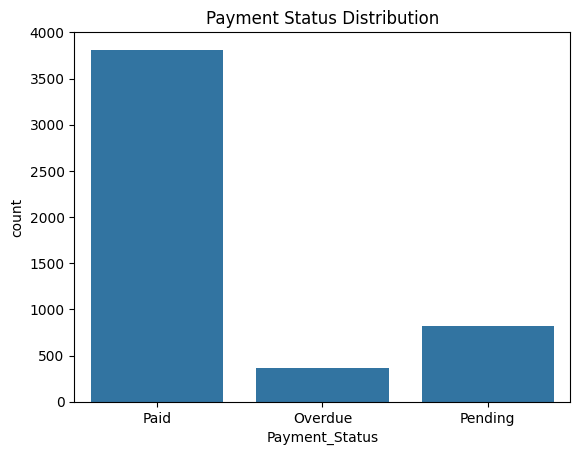

In [9]:
sns.countplot(
    x='Payment_Status',
    data=df
)

plt.title('Payment Status Distribution')
plt.show()